<a href="https://colab.research.google.com/github/Smyles019/html-login-form-detector/blob/feat%2Fxgboost/notebooks/02_xgboost_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!git clone https://github.com/Smyles019/html-login-form-detector.git

Cloning into 'html-login-form-detector'...
remote: Enumerating objects: 110, done.
remote: Counting objects: 100% (110/110), done.
remote: Compressing objects: 100% (94/94), done.
remote: Total 110 (delta 37), reused 38 (delta 10), pack-reused 0 (from 0)
Receiving objects: 100% (110/110), 390.13 KiB | 2.12 MiB/s, done.
Resolving deltas: 100% (37/37), done.


In [34]:
import os
import re
import shutil
import numpy as np
import pandas as pd
import xgboost as xgb
import joblib

from collections import Counter
from scipy.sparse import hstack
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print("XGBoost version:", xgb.__version__)

XGBoost version: 3.4.1


In [40]:
# 1. Reset processed directory
processed_path = 'data/processed'
if os.path.exists(processed_path):
    shutil.rmtree(processed_path)
os.makedirs(processed_path, exist_ok=True)

raw_path = 'data/raw/Dataset 1/'

label_mapping = {
    'LOGIN_FORM_MALICIOUS': 'LOGIN_FORM',
    'TEST_LOGIN_FORM': 'LOGIN_FORM',
    'LOGIN_FORM': 'LOGIN_FORM',
    'TEST_NO_FORM': 'NO_FORM',
    'NO_FORM': 'NO_FORM'
}

def load_and_validate(file_form, file_no_form, split_name):
    df1 = pd.read_csv(raw_path + file_form)
    df2 = pd.read_csv(raw_path + file_no_form)
    df = pd.concat([df1, df2], ignore_index=True)

    # --- 01-style validation checks ---
    n_missing_sig = df['html_signature'].isna().sum()
    n_missing_sha = df['sha256'].isna().sum()
    print(f"[{split_name}] Missing html_signature: {n_missing_sig} | Missing sha256: {n_missing_sha}")
    df['html_signature'] = df['html_signature'].fillna('')

    # Duplicate signatures + label-conflict check
    sig_label_check = df.groupby('html_signature')['label'].agg(
        sample_count='count', unique_labels='nunique'
    )
    conflicting = sig_label_check[sig_label_check['unique_labels'] > 1]
    print(f"[{split_name}] Unique signatures: {df['html_signature'].nunique()} | "
          f"Repeated: {(sig_label_check['sample_count'] > 1).sum()} | "
          f"Conflicting-label signatures: {len(conflicting)}")

    # Drop rows whose signature is conflicting (ambiguous ground truth)
    if len(conflicting) > 0:
        df = df[~df['html_signature'].isin(conflicting.index)].reset_index(drop=True)
        print(f"[{split_name}] Dropped {len(conflicting)} conflicting signatures' rows")

    # Dedupe on html_signature (keep first)
    before = len(df)
    df = df.drop_duplicates(subset='html_signature', keep='first').reset_index(drop=True)
    print(f"[{split_name}] Dedup removed {before - len(df)} rows -> {len(df)} remaining")

    # Map to final label schema
    df['clean_label'] = df['label'].map(label_mapping).fillna(df['label'])

    return df

df_train = load_and_validate('train_login_form.csv', 'train_no_form.csv', 'TRAIN')
df_val = load_and_validate('validation_login_form.csv', 'validation_no_form.csv', 'VAL')

df_train.to_csv(f'{processed_path}/train_cleaned.csv', index=False)
df_val.to_csv(f'{processed_path}/validation_cleaned.csv', index=False)

print("\nUnique labels in Train:", df_train['clean_label'].unique())
print("Unique labels in Val:  ", df_val['clean_label'].unique())
print(f"Data cleaned & saved! Train: {len(df_train)} rows | Val: {len(df_val)} rows")

[TRAIN] Missing html_signature: 2 | Missing sha256: 0
[TRAIN] Unique signatures: 1141 | Repeated: 34 | Conflicting-label signatures: 0
[TRAIN] Dedup removed 42 rows -> 1141 remaining
[VAL] Missing html_signature: 0 | Missing sha256: 0
[VAL] Unique signatures: 205 | Repeated: 3 | Conflicting-label signatures: 0
[VAL] Dedup removed 3 rows -> 205 remaining

Unique labels in Train: ['LOGIN_FORM' 'NO_FORM']
Unique labels in Val:   ['LOGIN_FORM' 'NO_FORM']
Data cleaned & saved! Train: 1141 rows | Val: 205 rows


In [41]:
def extract_structural_features(sig):
    """From notebook 01 — general-purpose structural counts."""
    tags = re.findall(r'[a-zA-Z][a-zA-Z0-9]*', sig.lower())
    tag_counts = Counter(tags)

    max_depth = 0
    current_depth = 0
    for char in sig:
        if char == '(':
            current_depth += 1
            max_depth = max(max_depth, current_depth)
        elif char == ')':
            current_depth = max(0, current_depth - 1)

    return {
        'signature_length': len(sig),
        'max_depth': max_depth,
        'total_tags': len(tags),
        'unique_tags_count': len(tag_counts),
        'form_count': tag_counts.get('form', 0),
        'input_count': tag_counts.get('input', 0),
        'button_count': tag_counts.get('button', 0),
        'script_count': tag_counts.get('script', 0),
        'label_count': tag_counts.get('label', 0),
        'a_count': tag_counts.get('a', 0),
        'div_count': tag_counts.get('div', 0),
    }

def extract_structural_topology(sig):
    """From notebook 02 — login-form-specific sequential/ratio signals."""
    s = str(sig).lower()

    c_form = s.count('(form')
    c_input = s.count('(input')
    c_button = s.count('(button')
    c_label = s.count('(label')
    c_a = s.count('(a')
    c_div = s.count('(div')

    has_form_input = 1 if re.search(r'\(form.*\(input', s) else 0
    has_multi_input = 1 if c_input >= 2 else 0
    has_input_button = 1 if re.search(r'\(input.*\(button', s) else 0
    has_form_button = 1 if re.search(r'\(form.*\(button', s) else 0

    input_to_div_ratio = c_input / (c_div + 1)

    return {
        'topo_form_count': c_form,
        'topo_input_count': c_input,
        'topo_button_count': c_button,
        'topo_label_count': c_label,
        'topo_a_count': c_a,
        'topo_div_count': c_div,
        'has_form_input': has_form_input,
        'has_multi_input': has_multi_input,
        'has_input_button': has_input_button,
        'has_form_button': has_form_button,
        'input_to_div_ratio': input_to_div_ratio,
    }

def clean_signature_tokens(sig):
    """01-style plain tag tokens — kept only for optional inspection, not used as the vectorizer input."""
    tags = re.findall(r'[a-zA-Z][a-zA-Z0-9]*', sig.lower())
    return ' '.join(tags)


# Load cleaned data
df_train = pd.read_csv('data/processed/train_cleaned.csv')
df_val = pd.read_csv('data/processed/validation_cleaned.csv')
df_train['html_signature'] = df_train['html_signature'].fillna('')
df_val['html_signature'] = df_val['html_signature'].fillna('')

label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(df_train['clean_label'].astype(str))
y_val = label_encoder.transform(df_val['clean_label'].astype(str))

# Structural features (01) + topology features (02), merged
struct_train = pd.DataFrame([extract_structural_features(s) for s in df_train['html_signature']])
struct_val = pd.DataFrame([extract_structural_features(s) for s in df_val['html_signature']])

topo_train = pd.DataFrame([extract_structural_topology(s) for s in df_train['html_signature']])
topo_val = pd.DataFrame([extract_structural_topology(s) for s in df_val['html_signature']])

numeric_train = pd.concat([struct_train, topo_train], axis=1)
numeric_val = pd.concat([struct_val, topo_val], axis=1)

print(f"Merged numeric feature matrix: {numeric_train.shape[1]} features")
print(numeric_train.columns.tolist())

Merged numeric feature matrix: 22 features
['signature_length', 'max_depth', 'total_tags', 'unique_tags_count', 'form_count', 'input_count', 'button_count', 'script_count', 'label_count', 'a_count', 'div_count', 'topo_form_count', 'topo_input_count', 'topo_button_count', 'topo_label_count', 'topo_a_count', 'topo_div_count', 'has_form_input', 'has_multi_input', 'has_input_button', 'has_form_button', 'input_to_div_ratio']


In [42]:
# Tag n-gram sequences (paren-style tokens, per our agreed tokenization)
seq_vectorizer = CountVectorizer(
    token_pattern=r'\([a-z0-9]+|\)',
    ngram_range=(1, 5),
    max_features=4000
)
X_train_seq = seq_vectorizer.fit_transform(df_train['html_signature'])
X_val_seq = seq_vectorizer.transform(df_val['html_signature'])

print(f"N-gram matrix — Train: {X_train_seq.shape}, Val: {X_val_seq.shape}")

# Scale the merged numeric features (structural + topology)
scaler = RobustScaler()
X_train_num = scaler.fit_transform(numeric_train)
X_val_num = scaler.transform(numeric_val)

# Combine numeric + n-gram into one sparse matrix
X_train = hstack([X_train_num, X_train_seq]).tocsr()
X_val = hstack([X_val_num, X_val_seq]).tocsr()

print(f"Final combined matrix — X_train: {X_train.shape}, X_val: {X_val.shape}")

N-gram matrix — Train: (1141, 4000), Val: (205, 4000)
Final combined matrix — X_train: (1141, 4022), X_val: (205, 4022)


In [43]:
model = xgb.XGBClassifier(
    n_estimators=1000,
    learning_rate=0.02,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    scale_pos_weight=3.5,        # Heavy penalty on false negatives (missing LOGIN_FORM)
    early_stopping_rounds=40,
    random_state=42,
    eval_metric='auc'
)

model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=50
)

[0]	validation_0-auc:0.72249
[50]	validation_0-auc:0.89830
[100]	validation_0-auc:0.91548
[150]	validation_0-auc:0.92685
[200]	validation_0-auc:0.93166
[250]	validation_0-auc:0.93423
[270]	validation_0-auc:0.93432


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=40,
              enable_categorical=True, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.02, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=1000,
              n_jobs=None, num_parallel_tree=None, ...)

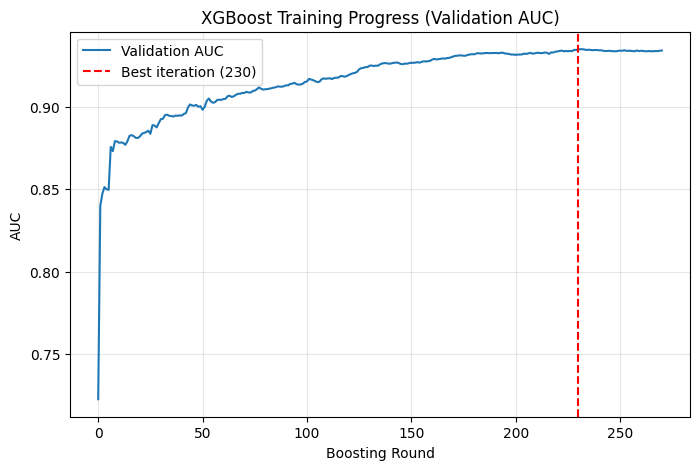

In [44]:
import matplotlib.pyplot as plt

results = model.evals_result()
val_auc = results['validation_0']['auc']

plt.figure(figsize=(8, 5))
plt.plot(val_auc, label='Validation AUC')
plt.axvline(model.best_iteration, color='red', linestyle='--',
            label=f'Best iteration ({model.best_iteration})')
plt.xlabel('Boosting Round')
plt.ylabel('AUC')
plt.title('XGBoost Training Progress (Validation AUC)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [45]:
# Probabilities for Class 0 (LOGIN_FORM) and Class 1 (NO_FORM)
y_proba_login = model.predict_proba(X_val)[:, 0]
y_proba_no_form = model.predict_proba(X_val)[:, 1]

# Calibrated decision boundary for security focus
login_threshold = 0.20
y_pred_adjusted = np.where(y_proba_login >= login_threshold, 0, 1)

print(f"=== Adjusted Evaluation (LOGIN_FORM Threshold = {login_threshold}) ===")
print(classification_report(y_val, y_pred_adjusted, target_names=label_encoder.classes_))

roc_score = roc_auc_score(y_val, y_proba_no_form)
print(f"Corrected ROC-AUC Score: {roc_score:.4f}")

cm = confusion_matrix(y_val, y_pred_adjusted)
cm_df = pd.DataFrame(
    cm,
    index=[f"Actual {c}" for c in label_encoder.classes_],
    columns=[f"Pred {c}" for c in label_encoder.classes_]
)
print("\n=== Confusion Matrix ===")
print(cm_df)

=== Adjusted Evaluation (LOGIN_FORM Threshold = 0.2) ===
              precision    recall  f1-score   support

  LOGIN_FORM       0.94      0.71      0.81       103
     NO_FORM       0.76      0.95      0.85       102

    accuracy                           0.83       205
   macro avg       0.85      0.83      0.83       205
weighted avg       0.85      0.83      0.83       205

Corrected ROC-AUC Score: 0.9351

=== Confusion Matrix ===
                   Pred LOGIN_FORM  Pred NO_FORM
Actual LOGIN_FORM               73            30
Actual NO_FORM                   5            97


In [46]:
os.makedirs('models', exist_ok=True)
joblib.dump(model, 'models/xgboost_model.pkl')
joblib.dump(seq_vectorizer, 'models/vectorizer.pkl')
joblib.dump(scaler, 'models/scaler.pkl')
joblib.dump(label_encoder, 'models/label_encoder.pkl')

print("Complete model pipeline successfully saved to 'models/'!")

Complete model pipeline successfully saved to 'models/'!


In [47]:
false_negatives_mask = (y_val == 0) & (y_pred_adjusted == 1)
fn_signatures = df_val.loc[false_negatives_mask, 'html_signature']

print(f"Total Missed Login Forms: {len(fn_signatures)}\n")
print("=== Sample of Missed HTML Signatures ===")
for i, sig in enumerate(fn_signatures.head(5), 1):
    print(f"\n--- Missed Form #{i} ---")
    print(sig[:300])

Total Missed Login Forms: 30

=== Sample of Missed HTML Signatures ===

--- Missed Form #1 ---
(body(div(div)(img)(div)(div(img))(div(div(div(div)(div)(div)(div)(div)(div)(label)(input)(div)(label)(img)(input)(div)(div)(div)(div)(center)))))(div)(script)(script)(script)(script)(script)(script))

--- Missed Form #2 ---
(body(div(div(div(div(div)(div)(div(div)(button(div))))))(div(div(div(div)(div)(div(div)(button(div))))))(div(div(div(div)(div)(div(div)(button(div))(button(div))))))(div(div(div(div(div(div(div)))))))(div(div(div(div(div(div)(div)(div))))(div(div(div(div(div(div)(div)(div)))(form(div(div)(div(div(d

--- Missed Form #3 ---
(body(div(style)(img)(span(img)))(div(div(div(div(div(div)))(div(div(div(div(div(div(section(main(div(div(div(div(div))(div(div(form(div(div(span))(div(div(label(span)(input))(div)))(div(div(label(span)(input))(div)))(div(button(div)))(div(div(div)(div)(div)))(div(button(span)(span))))(a(span))))))(

--- Missed Form #4 ---
(body(main(div(div(img)(div(fo